In [1]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data.2014 <- read_csv("..//data/output/data-2014-new.csv")
data.2015 <- read_csv("..//data/output/data-2015.csv")
data.2016 <- read_csv("..//data/output/data-2016.csv")
data.2017 <- read_csv("..//data/output/data-2017.csv")
data.2018 <- read_csv("..//data/output/data-2018-ffs.csv")
data.2019 <- read_csv("..//data/output/data-2019.csv")

Rows: 62344 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (42): planid, fips, year, n_nonmiss, avg_enrollment, sd_enrollment, min_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 65499 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (42): planid, fips, year, n_nonmiss, avg_enrollment, sd_enrollment, min_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68774 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): 

In [9]:
combined <- bind_rows(
  data.2014,
  data.2015,
  data.2016,
  data.2017,
  data.2018,
  data.2019
)

In [10]:
combined <- combined %>% mutate (basic_premium = case_when(
        rebate_partc > 0 ~ 0,
        partd == "No" & !is.na(premium) & is.na(premium_partc) ~ premium,
        TRUE ~ premium_partc
      ),
      bid = case_when(
        rebate_partc == 0 & basic_premium > 0 ~ (payment_partc + basic_premium) / riskscore_partc,
        rebate_partc > 0  | basic_premium == 0 ~  payment_partc / riskscore_partc,
        TRUE ~ NA_real_
      )
                                 )

In [11]:
glimpse(combined)

Rows: 449,046
Columns: 65
$ contractid          <chr> "H0022", "H0022", "H0022", "H0022", "H0022", "H002…
$ planid              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4,…
$ fips                <dbl> 39023, 39035, 39051, 39055, 39057, 39085, 39093, 3…
$ year                <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ n_nonmiss           <dbl> 6, 8, 7, 0, 6, 8, 8, 7, 8, 6, 4, 7, 12, 12, 12, 12…
$ avg_enrollment      <dbl> 72.00000, 330.12500, 24.57143, NA, 120.83333, 41.5…
$ sd_enrollment       <dbl> 7.2111026, 10.6158574, 1.8126539, NA, 15.7659972, …
$ min_enrollment      <dbl> 60, 309, 23, NA, 90, 39, 29, 299, 24, 431, 11, 71,…
$ max_enrollment      <dbl> 81, 344, 28, NA, 135, 44, 43, 440, 26, 713, 12, 85…
$ first_enrollment    <dbl> 60, 309, 24, NA, 90, 41, 29, 299, 24, 431, 11, 71,…
$ last_enrollment     <dbl> 81, 344, 24, NA, 135, 44, 43, 440, 24, 713, 12, 82…
$ state               <chr> "OH", "OH", "OH", "OH", "OH", "OH", "OH", "OH", "O…
$ county      

Problem 1

In [12]:
plans_unique <- combined %>%
  # Part D but no Part C premium
  filter(!(partd == "Yes" & is.na(premium_partc))) 
  # distinct(fips, year, contractid, planid)

In [13]:
plan_counts <- plans_unique %>%
  group_by(fips, year) %>%
  summarise(
    plan_count = n(),
    .groups = "drop"
  )

summary(plan_counts$plan_count)
max(plan_counts$plan_count)
mean(plan_counts$plan_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    5.00    9.00   11.17   15.00   61.00 

[1] 61

[1] 11.1708

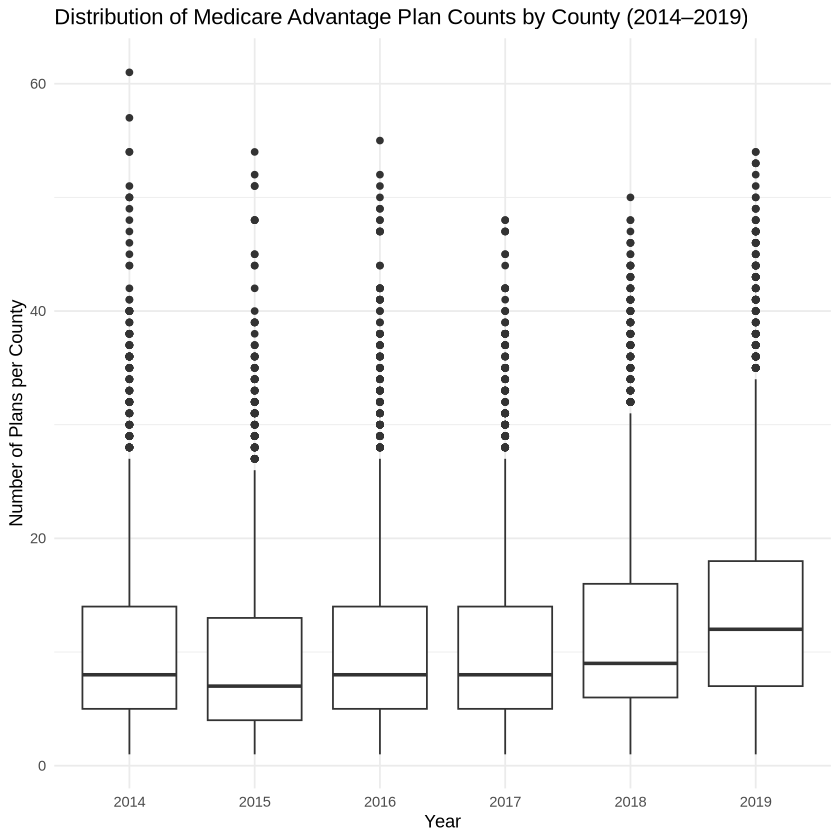

In [14]:
ggplot(plan_counts, aes(x = factor(year), y = plan_count)) +
  geom_boxplot() +
  labs(
    x = "Year",
    y = "Number of Plans per County",
    title = "Distribution of Medicare Advantage Plan Counts by County (2014–2019)"
  ) +
  theme_minimal()


In [15]:
#plan_counts <- combined %>% 
#group_by(fips)%>% 
#count(fips, year, name = "plan_count")

In [16]:
#boxplot(plan_count ~ year, data = plan_counts,
        #xlab = "Year",
        #ylab = "Plan count",
        #main = "Distribution of plan counts by year" )

Problem 2

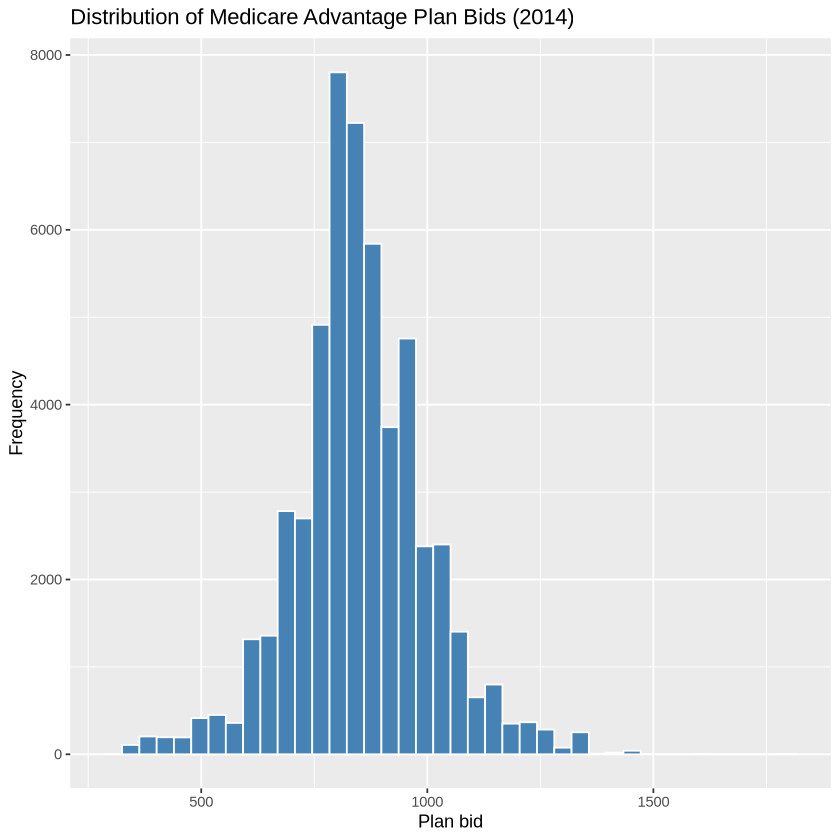

In [17]:
ggplot(filter(combined, year == 2014, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2014)",
    x = "Plan bid",
    y = "Frequency"
  ) 

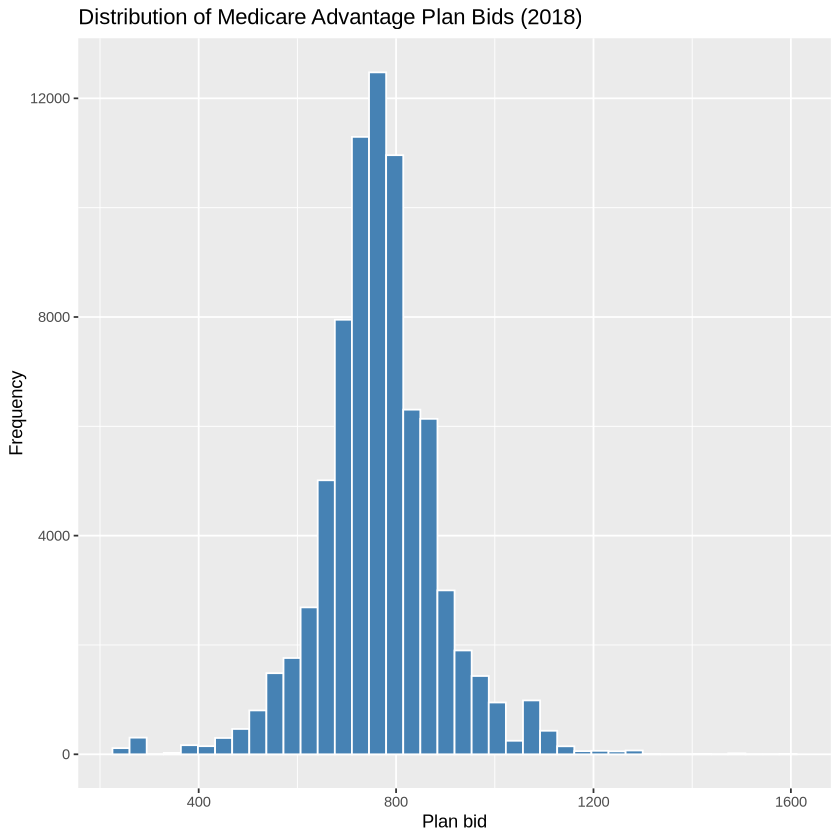

In [18]:
ggplot(filter(combined, year == 2018, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2018)",
    x = "Plan bid",
    y = "Frequency"
  ) 

Problem 3

In [19]:
combined_hhi <- combined %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year) %>%
  mutate(market_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()


In [20]:
county_hhi <- combined_hhi %>%
  group_by(fips, year) %>%
  summarise(
    hhi = sum(market_share^2),
    .groups = "drop"
  )

In [21]:
avg_hhi <- county_hhi %>%
  group_by(year) %>%
  summarise(
    avg_hhi = mean(hhi),
    .groups = "drop"
  )

In [22]:
avg_hhi

year,avg_hhi
<dbl>,<dbl>
2014,0.1826015
2015,0.1778957
2016,0.1772325
2017,0.1665723
2018,0.1457807
2019,0.1256304


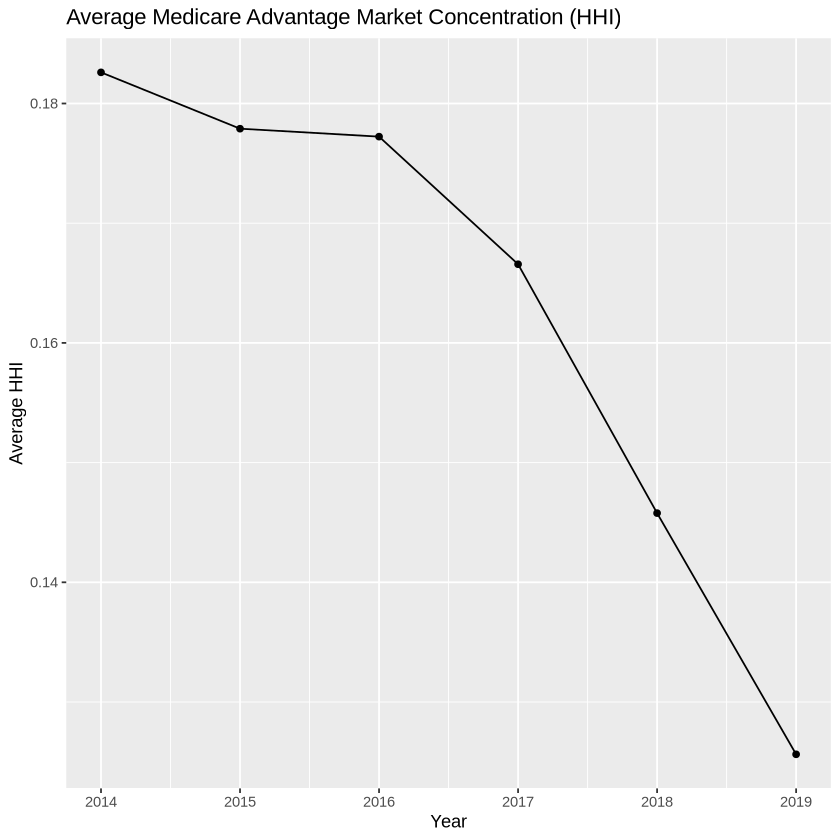

In [23]:
ggplot(avg_hhi, aes(x = year, y = avg_hhi)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Medicare Advantage Market Concentration (HHI)",
    x = "Year",
    y = "Average HHI"
  )

Problem 4

In [24]:
ma_year <- combined %>%
  group_by(year) %>%
    mutate(ma_share = avg_enrolled / avg_eligibles) %>%
    summarise(
    mean_ma_share = mean(ma_share, na.rm = TRUE),
    .groups = "drop"
  )

In [25]:
knitr::kable(
  ma_year,
  digits = 6,
  col.names = c("Year", "Mean MA Enrollment Share"),
  caption = "Average Share of Medicare Advantage (2014–2019)"
)



Table: Average Share of Medicare Advantage (2014–2019)

| Year| Mean MA Enrollment Share|
|----:|------------------------:|
| 2014|                 0.283879|
| 2015|                 0.297622|
| 2016|                 0.304065|
| 2017|                 0.316923|
| 2018|                 0.325687|
| 2019|                 0.353336|

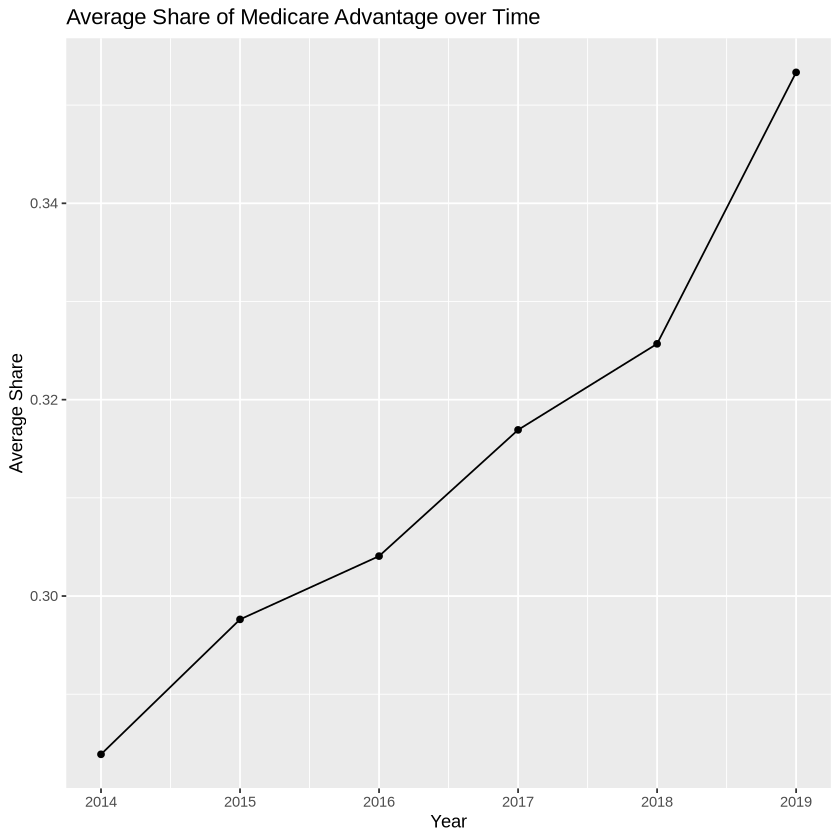

In [26]:
ggplot(ma_year, aes(x = year, y =  mean_ma_share)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Share of Medicare Advantage over Time",
    x = "Year",
    y = "Average Share"
  )

Problem 5

In [27]:
marketshare2018 <- data.2018 %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year) %>%
  mutate(market_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()

In [28]:
hhi_by_county <- marketshare2018 %>%
  group_by(fips) %>%
  summarize(hhi = sum(market_share^2, na.rm = TRUE), .groups = "drop")
  # summarise(mean_bid = mean(bid, na.rm = TRUE), .groups = "drop")


In [29]:
hhi_33 <- quantile(hhi_by_county$hhi, 0.33, na.rm = TRUE)
hhi_66 <- quantile(hhi_by_county$hhi, 0.66, na.rm = TRUE)

In [30]:
hhi_by_county <- hhi_by_county %>%
  mutate(market_type = case_when(
    hhi <= hhi_33 ~ "Competitive",
    hhi >= hhi_66 ~ "Uncompetitive",
    TRUE ~ NA_character_
  ))

In [31]:
plan_level <- marketshare2018 %>%
  left_join(hhi_by_county, by = "fips") %>%
  filter(!is.na(market_type), !is.na(bid))

county_mean_bid <- plan_level %>%
  group_by(fips, market_type) %>%
  summarise(mean_bid = mean(bid, na.rm = TRUE), .groups = "drop")
        # i want to collapse all plans in one county to one (instead of mutate)

avg_bid_by_market <- county_mean_bid %>%
  group_by(market_type) %>%
  summarise(avg_bid = mean(mean_bid), .groups = "drop")


In [32]:
knitr::kable(
  avg_bid_by_market,
  digits = 2,
  col.names = c("Market Type", "Average Bid"),
  caption = "Average Medicare Advantage Bid by Market Competitiveness (2018)"
)



Table: Average Medicare Advantage Bid by Market Competitiveness (2018)

|Market Type   | Average Bid|
|:-------------|-----------:|
|Competitive   |      782.86|
|Uncompetitive |      788.32|

In [33]:
# marketshare2018 <- data.2018 %>%
#   filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
#   filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
#   group_by(fips, year) %>%
#   mutate(market_share = avg_enrollment / avg_enrolled
#   ) %>%
#   ungroup()


In [34]:
# hhi_2018 <- marketshare2018 %>%
#   group_by(fips) %>%
#   mutate(
#     hhi = sum(market_share^2, na.rm = TRUE),
#   )%>%
#   ungroup()

In [35]:
# avg_bid_by_market <- hhi_2018 %>%
#   filter(!is.na(market_type), !is.na(bid)) %>%
#   group_by(market_type) %>%
#   summarise(
#     avg_bid = mean(bid),
#     .groups = "drop"
#   )

In [36]:
# print(avg_bid_by_market)

Problem 6

In [37]:
# ffs.2018 <- read_csv("..//data/output/data-2018-ffs.csv")

In [38]:
# colnames(ffs.2018)

In [39]:
data.2018.ffs <- data.2018 %>%
  mutate(
    ffscost_q = ntile(avg_ffscost, 4)
  )
# made 4 quartiles here 

In [4]:
q1 <- data.2018.ffs%>%
  mutate(treated = if_else(ffscost_q == 1, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q1")

q2 <-  data.2018.ffs %>%
  mutate(treated = if_else(ffscost_q == 2, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q2")

q3 <- data.2018.ffs %>%
  mutate(treated = if_else(ffscost_q == 3, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q3")

q4 <- data.2018.ffs %>%
  mutate(treated = if_else(ffscost_q == 4, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q4")

In [5]:
big_avg_table <- bind_rows(q1, q2, q3, q4) %>%
  select(quartile, treated, avg_bid, n)%>%
  filter(!is.na(treated))

In [6]:
knitr::kable(
  big_avg_table,
  digits = 5,
  col.names = c("Quartile", "Treated/Control", "Average Bid", "n"),
  caption = "Average Bid for Treated/Control Groups per Quartile(2018)"
)



Table: Average Bid for Treated/Control Groups per Quartile(2018)

|Quartile |Treated/Control | Average Bid|     n|
|:--------|:---------------|-----------:|-----:|
|Q1       |Control         |    761.3458| 64355|
|Q1       |Treated         |    778.7275| 21452|
|Q2       |Control         |    764.2578| 64355|
|Q2       |Treated         |    769.9289| 21452|
|Q3       |Control         |    768.2317| 64355|
|Q3       |Treated         |    758.0963| 21452|
|Q4       |Control         |    768.8580| 64356|
|Q4       |Treated         |    756.0814| 21451|

Problem 7

In [7]:
options(repos = c(CRAN = "https://cran.rstudio.com/"))
install.packages("MatchIt")
install.packages("Matching")

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [47]:
analysis <- data.2018.ffs %>%
  left_join(hhi_by_county %>% select(fips, market_type), by = "fips") %>%
  mutate(
    high_hhi  = as.integer(market_type == "Uncompetitive"),
    ffscost_q = as.integer(ffscost_q)
  ) %>%
  filter(!is.na(bid), !is.na(high_hhi), !is.na(ffscost_q))

In [49]:
nrow(analysis)
count(analysis, fips) %>% summarise(max_n = max(n))
hhi_by_county %>%
  count(fips) %>%
  summarise(max_dupes = max(n))

[1] 50005

max_n
<int>
370


max_dupes
<int>
1


In [40]:
# market_type_by_fips <- hhi_by_county %>%
#   select(fips, market_type) %>%
#   distinct(fips, .keep_all = TRUE)

# analysis <- data.2018.ffs %>%
#   left_join(market_type_by_fips, by = "fips") %>%
#   mutate(
#     high_hhi  = if_else(market_type == "Uncompetitive", 1L, 0L),
#     ffscost_q = as.integer(ffscost_q)
#   ) %>%
#   filter(!is.na(bid), !is.na(high_hhi), !is.na(ffscost_q))

In [41]:
# nrow(data.2018.ffs)
# nrow(analysis)

[1] 85866

[1] 50005

In [50]:
# Xq <- model.matrix(~ factor(ffscost_q), data = analysis)[, -1, drop = FALSE]

In [51]:
# nn_inv <- Matching::Match(
#   Y = analysis$bid,
#   Tr = analysis$high_hhi,
#   X = Xq,
#   M = 1,
#   Weight = 1,
#   estimand = "ATE",
#   exact = TRUE,
#   ties = FALSE,
#   version = "fast"
# )

In [52]:
# nn_inv$est
# nn_inv$se

1.930704


NULL

In [53]:
# nn_mah <- Matching::Match(
#   Y = analysis$bid,
#   Tr = analysis$high_hhi,
#   X = Xq,
#   M = 1,
#   Weight = 2,
#   estimand = "ATE",
#   exact = TRUE,
#   ties = FALSE,
#   version = "fast"
# )

In [54]:
# nn_mah$est
# nn_mah$se

2.258947


NULL

In [55]:
analysis2 <- analysis %>% 
  filter(!is.na(bid), !is.na(high_hhi), !is.na(ffscost_q), !is.na(avg_ffscost)) %>%
  arrange(ffscost_q, high_hhi, fips, bid)

nn_inv <- Matching::Match(
  Y = analysis2$bid,
  Tr = analysis2$high_hhi,
  X = analysis2$avg_ffscost,   # distance variable
  exact = analysis2$ffscost_q, # <-- match only within quartile
  M = 1,
  Weight = 1,                 # inverse-variance distance
  estimand = "ATE",
  ties = TRUE,
  version = "fast"
)

Warning message in Matching::Match(Y = analysis2$bid, Tr = analysis2$high_hhi, X = analysis2$avg_ffscost, :
“length of exact != ncol(X). Ignoring exact option”


In [56]:
nn_inv$est

6.248468


In [57]:
X <- cbind(analysis2$avg_ffscost)

nn_mah <- Matching::Match(
  Y = analysis2$bid,
  Tr = analysis2$high_hhi,
  X = X,
  exact = analysis2$ffscost_q,
  M = 1,
  Weight = 2,          # Mahalanobis
  estimand = "ATE",
  ties = TRUE,
  version = "fast"
)

nn_mah$est


Warning message in Matching::Match(Y = analysis2$bid, Tr = analysis2$high_hhi, X = X, :
“length of exact != ncol(X). Ignoring exact option”


6.248468


In [ ]:
ps_model <- glm(
  high_hhi ~ factor(ffscost_q),
  data = analysis,
  family = binomial
)

analysis <- analysis %>%
  mutate(pscore = predict(ps_model, type = "response"))


In [38]:
# analysis <- data.2018.ffs %>%
#   left_join(plan_level %>% select(fips, market_type), by = "fips") %>%
#   mutate(
#     high_hhi = ifelse(market_type == "Uncompetitive", 1, 0),
#     ffscost_q = as.integer(ffscost_q)
#   ) %>%
#   filter(!is.na(bid), !is.na(high_hhi), !is.na(ffscost_q))


Warning message in left_join(., plan_level %>% select(fips, market_type), by = "fips"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 3 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [72]:
Xq <- model.matrix(~ factor(ffscost_q), data = analysis)[, -1, drop = FALSE]

In [ ]:
nn_inv <- Matching::Match(
  Y = analysis$bid,
  Tr = analysis$high_hhi,
  X  = Xq,           # <-- ONLY quartile dummies
  M = 1,             # 1-to-1
  Weight = 1,        # inverse-variance distance
  estimand = "ATE",
  ties = FALSE
)

m_inv$est    # ATE point estimate
m_inv$se

In [67]:
# #analysis <- data.2018.ffs %>%
#  # group_by(fips) %>%
#   # summarize(hhi = sum(market_share^2, na.rm = TRUE), .groups = "drop")

# hhi_by_county <- marketshare2018 %>%
#   group_by(fips) %>%
#   summarize(hhi = sum(market_share^2, na.rm = TRUE), .groups = "drop")  
# left_join(
#     plan_level %>% select(fips, market_type),
#     by = "fips"
#   ) %>%
#   mutate(
#     high_hhi = ifelse(market_type == "Uncompetitive", 1, 0),
#     ffscost_q = as.integer(ffscost_q)
#   ) %>%
#   filter(
#     !is.na(bid),
#     !is.na(high_hhi),
#     !is.na(ffscost_q)
#   )

Warning message in left_join(., plan_level %>% select(fips, market_type), by = "fips"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 3 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [68]:
glimpse (analysis)

Rows: 863,105
Columns: 68
$ contractid          <chr> "H0028", "H0028", "H0028", "H0028", "H0028", "H002…
$ planid              <dbl> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8, 8, 8, 8, 8, 8,…
$ fips                <dbl> 15003, 15003, 15003, 15003, 15003, 15003, 15003, 1…
$ year                <dbl> 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 20…
$ n_nonmiss           <dbl> 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12…
$ avg_enrollment      <dbl> 2786.2500, 2786.2500, 2786.2500, 2786.2500, 2786.2…
$ sd_enrollment       <dbl> 55.22866, 55.22866, 55.22866, 55.22866, 55.22866, …
$ min_enrollment      <dbl> 2731, 2731, 2731, 2731, 2731, 2731, 2731, 2731, 27…
$ max_enrollment      <dbl> 2909, 2909, 2909, 2909, 2909, 2909, 2909, 2909, 29…
$ first_enrollment    <dbl> 2909, 2909, 2909, 2909, 2909, 2909, 2909, 2909, 29…
$ last_enrollment     <dbl> 2744, 2744, 2744, 2744, 2744, 2744, 2744, 2744, 27…
$ state               <chr> "HI", "HI", "HI", "HI", "HI", "HI", "HI", "HI", "H…
$ county      

In [62]:
dat_q1 <- data.2018.ffs %>%
  mutate(
    treat   = ifelse(ffscost_q == 1, 1, 0),  # treated = in Q1
    outcome = bid,                           # outcome
    covar   = avg_ffscost                    # matching covariate
  ) %>%
  filter(!is.na(outcome), !is.na(covar), !is.na(treat))

# Nearest-neighbor matching
nn_q1 <- Matching::Match(
  Y = dat_q1$outcome,
  Tr = dat_q1$treat,
  X = dat_q1$covar,
  M = 1,              # 1-to-1
  estimand = "ATE",
  ties = FALSE
)

In [63]:
data.frame(
  quartile = "Q1",
  ATE = nn_q1$est,
  SE  = nn_q1$se.standard
)

quartile,ATE,SE
<chr>,<dbl>,<dbl>
Q1,-97.25991,0.6318307


In [34]:
ate_results <- lapply(1:4, function(q) {

dat_q <- ffs.2018 %>%
    mutate(
      treat = ifelse(ffscost_q == q, 1, 0),
      outcome = bid,
      covar = avg_ffscost
    )

dat_q <- dat_q %>% 
  filter(!is.na(outcome), !is.na(treat), !is.na(covar))

nn2 <- Matching::Match(
    Y = dat_q$outcome,
    Tr = dat_q$treat,
    X = dat_q$covar,
    M = 1,
    Weight = 1,
    estimand = "ATE",
    ties=FALSE
  )

  data.frame(
    quartile = q,
    ATE = nn2$est
  )
})

ate_table <- do.call(rbind, ate_results)

print(ate_table)

  quartile       ATE
1        1 -97.16771
2        2  14.48494
3        3  41.17377
4        4 -27.79567


In [55]:
print(ate_table)

  quartile       ATE
1        1 -97.16771
2        2  14.48494
3        3  41.17377
4        4 -27.79567


In [44]:
ate_results <- lapply(1:4, function(q) {

dat_q <- ffs.2018 %>%
    mutate(
      treat = ifelse(ffscost_q == q, 1, 0),
      outcome = bid,
      covar = avg_ffscost
    )

dat_q <- dat_q %>% 
  filter(!is.na(outcome), !is.na(treat), !is.na(covar))

nn2 <- Matching::Match(
    Y = dat_q$outcome,
    Tr = dat_q$treat,
    X = dat_q$covar,
    M = 1,
    Weight = 2,
    estimand = "ATE",
    ties=FALSE
  )

  data.frame(
    quartile = q,
    ATE = nn2$est
  )
})

ate_table_2 <- do.call(rbind, ate_results)

print(ate_table_2)

  quartile       ATE
1        1 -97.73672
2        2  14.56085
3        3  41.31849
4        4 -28.11208


In [52]:
print(ate_table_2)

  quartile       ATE
1        1 -97.73672
2        2  14.56085
3        3  41.31849
4        4 -28.11208


In [46]:
ate_results <- lapply(1:4, function(q) {

  dat_q <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),   
      y = bid,
      x = ffscost_q                      
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x))

  logit.model <- glm(w ~ factor(x), family = binomial, data = dat_q)
  ps <- fitted(logit.model)

  dat_q <- dat_q %>%
    mutate(ipw = case_when(
      w == 1 ~ 1 / ps,
      w == 0 ~ 1 / (1 - ps),
      TRUE ~ NA_real_
    ))

  mean.w1 <- dat_q %>%
    filter(w == 1) %>%
    summarise(mean_y = weighted.mean(y, ipw))

  mean.w0 <- dat_q %>%
    filter(w == 0) %>%
    summarise(mean_y = weighted.mean(y, ipw))

  data.frame(
    quartile = q,
    ATE_IPW = mean.w1$mean_y - mean.w0$mean_y
  )
})

ate_table_ipw <- do.call(rbind, ate_results)
print(ate_table_ipw)


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


  quartile    ATE_IPW
1        1  17.381757
2        2   5.671065
3        3 -10.135400
4        4 -12.776548


In [53]:
print(ate_table_ipw)

  quartile    ATE_IPW
1        1  17.381757
2        2   5.671065
3        3 -10.135400
4        4 -12.776548


In [48]:
ate_results_reg <- lapply(1:4, function(q) {

  select.dat <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),
      y = bid,
      x = ffscost_q
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x))

  reg <- lm(y ~ w * factor(x), data = select.dat)

  pred1 <- predict(reg, newdata = transform(select.dat, w = 1))
  pred0 <- predict(reg, newdata = transform(select.dat, w = 0))

  ate <- mean(pred1 - pred0, na.rm = TRUE)

  data.frame(
    quartile = q,
    ATE_regression = ate
  )
})

ate_table_reg <- do.call(rbind, ate_results_reg)
print(ate_table_reg)


Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):


  quartile ATE_regression
1        1      22.646089
2        2      -8.798631
3        3     -20.631194
4        4     -22.646089


In [54]:
print(ate_table_reg)

  quartile ATE_regression
1        1      22.646089
2        2      -8.798631
3        3     -20.631194
4        4     -22.646089


In [49]:
saveRDS(ate_table_reg, "ate_table_reg.rds")

Problem 8

Nearest neighbor matching with inverse variance distance and with Mahalanobis distance have very similar average treatment effect values. However, when using inverse propensity weighting and simple linear regression, both methods output noticeably different values. 

Problem 9

In [50]:
ate_results_reg_cont <- lapply(1:4, function(q) {

  select.dat <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),
      y = bid,
      x1 = avg_ffscost,
      x2 = n_enrol
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x1), !is.na(x2))

  reg <- lm(y ~ w * (x1 + x2), data = select.dat)

  pred1 <- predict(reg, newdata = transform(select.dat, w = 1))
  pred0 <- predict(reg, newdata = transform(select.dat, w = 0))

  ate <- mean(pred1 - pred0, na.rm = TRUE)

  data.frame(
    quartile = q,
    ATE_regression_continuous = ate
  )
})

ate_table_reg_cont <- do.call(rbind, ate_results_reg_cont)
print(ate_table_reg_cont)


  quartile ATE_regression_continuous
1        1                -9.4984154
2        2                -0.1257976
3        3                -7.3484978
4        4                -2.7936440


In [56]:
print(ate_table_reg_cont)

  quartile ATE_regression_continuous
1        1                -9.4984154
2        2                -0.1257976
3        3                -7.3484978
4        4                -2.7936440


Problem 10

Working with this data allowed me to see how different estimators will give you vastly different values. One thing that I learned was that it is crucial to know what each name of the row represents so that there is no issue missing a part of the dataset. One thing that surprised me was how easy it was for library or model choices to cause errors or slow runtimes.